In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
from matplotlib.lines import Line2D
from scipy.stats import linregress
import statsmodels.api as sm

from phd_project.config import config

from standes.analysis.recorders import get_recorder, get_recorders

from fitpo import fit_cbf_backbone

cfg = config.load_config()

In [4]:
def _load_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

In [5]:
ROOT = cfg["analysis_data"]["dc2_sdof_fitting"]
root_2 = Path(r"E:\03_wp1pt4pt1_dc2_sdof_fitting_b")

In [6]:
# load the building dataset
with open(cfg["proc_data"]["dc2_casestudy_dataset"], "rb") as f:
    bdata_df = pickle.load(f)

bdata_df = bdata_df.set_index("name")
bdata_df = bdata_df.drop(columns="index")
bdata_df_3s = bdata_df[bdata_df["n_storeys"] == 3]
bdata_df

,n_storeys,roof_height,V_wind_GQWSI_LC1,V_wind_GQWSI_LC2,V_wind_GQWSI_LC3,T1_GQWSI_LC1,T1_GQWSI_LC2,T1_GQWSI_LC3,gravity_frame_elastic_baseshear,gravity_design_equivalent_seismic_baseshear,...,seismic_F5,seismic_F6,seismic_F7,seismic_V1,seismic_V2,seismic_V3,seismic_V4,seismic_V5,seismic_V6,seismic_V7
name,,,,,,,,,,,,,,,,,,,,,
3s_cbf_dc2_10,3,10500,19855.845357,33093.075595,19855.845357,0.884937,0.864221,0.875094,1.940971e+05,79905.842715,...,NaN,NaN,NaN,17069.007996,51207.023987,9.692758e+04,NaN,NaN,NaN,NaN
3s_cbf_dc2_20,3,10500,19855.845357,33093.075595,19855.845357,0.767450,0.749553,0.759012,3.858510e+05,79905.842715,...,NaN,NaN,NaN,39119.717226,117359.151677,2.221441e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_31,3,10500,19855.845357,33093.075595,19855.845357,0.634683,0.621273,0.629798,7.502664e+05,79905.842715,...,NaN,NaN,NaN,91541.379705,274624.139115,5.198243e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_41,3,10500,19855.845357,33093.075595,19855.845357,0.562798,0.551065,0.558700,9.831009e+05,79905.842715,...,NaN,NaN,NaN,135192.440416,405577.321247,7.676999e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_51,3,10500,19855.845357,33093.075595,19855.845357,0.537063,0.525928,0.533244,1.589369e+06,79905.842715,...,NaN,NaN,NaN,164623.935396,493871.806189,9.348288e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_61,3,10500,19855.845357,33093.075595,19855.845357,0.516356,0.505608,0.512619,1.876711e+06,79905.842715,...,NaN,NaN,NaN,192517.767849,577553.303547,1.093226e+06,NaN,NaN,NaN,NaN
3s_cbf_dc2_71,3,10500,19855.845357,33093.075595,19855.845357,0.499045,0.488803,0.495654,2.156086e+06,79905.842715,...,NaN,NaN,NaN,218973.773887,656921.321660,1.243458e+06,NaN,NaN,NaN,NaN
3s_cbf_dc2_102,3,10500,19855.845357,33093.075595,19855.845357,0.456553,0.446897,0.453017,2.971518e+06,79905.842715,...,NaN,NaN,NaN,291850.005736,875550.017208,1.657291e+06,NaN,NaN,NaN,NaN
3s_cbf_dc2_122,3,10500,19855.845357,33093.075595,19855.845357,0.437225,0.428202,0.434177,3.456972e+06,79905.842715,...,NaN,NaN,NaN,331534.014792,994602.044377,1.882640e+06,NaN,NaN,NaN,NaN


In [7]:
buildings = bdata_df.index
three_s = bdata_df[bdata_df["n_storeys"] == 3].index
five_s = bdata_df[bdata_df["n_storeys"] == 5].index
seven_s = bdata_df[bdata_df["n_storeys"] == 7].index

pocs = {}

for b in buildings:
    pocs[b] = _load_pushover_curve(ROOT / b)

# Inspection of Pushover Curves

In [8]:
# load the recorders for each building
recorders = {}
for b in buildings:
    recorder_file = ROOT / b / "pushover" / "recorders.pickle"
    sa = int(b.split("_")[-1])
    with open(recorder_file, "rb") as f:
        rec_list = pickle.load(f)
    recorders[b] = rec_list


## 3 Storey Buildings

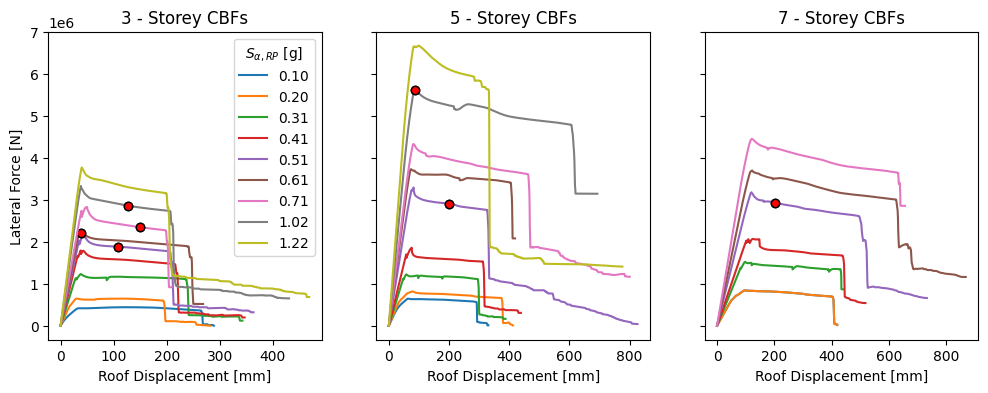

In [9]:
colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs, ns in zip([ax1, ax2, ax3], [three_s, five_s, seven_s], [3, 5, 7]):

    for b, colour in zip(bs[:], colours):
        # plot the po curve
        poc = pocs[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(poc[:, 0], poc[:, 1], color=colour, label = f"{sa:.2f}")

        # find and plot the points at which the limitstates are exceeded
        gusset_ls_recorders = get_recorders(recorders[b], "zerolength_force_limit_state")
        
        for tag, r in gusset_ls_recorders.items():
            if r.limit_state_exceeded:
                pt = poc[r.step_exceeded, :]
                if r.tag.split("_")[2] == "boltmoment":
                    mark = "s"
                elif r.tag.split("_")[2] == "tearout":
                    mark = "*"
                elif r.tag.split("_")[2] == "boltshear":
                    mark = "o"
                
                ax.plot(*pt, marker=mark, ls="", mec="k", mfc="r")

    
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
ax1.legend(title=r"$S_{\alpha, RP}$ [g]")


In several of the structures the bolts for the tension brace on the first floor are failing.

Post buckling -ve slope is steeper for the structures with a higher seismic design force 

## Fitting Pushover curves

In [10]:
def calculate_bb_params_from_fit(bb: np.ndarray):
    ke = bb[1, 1] / bb[1, 0]    # elastic stiffness
    
    theta_pb = bb[2, 0] - bb[1, 0]
    kpb = (bb[2, 1] - bb[1, 1]) / theta_pb

    theta_f = bb[3, 0] - bb[2, 0]
    kf = (bb[3, 1] - bb[2, 1]) / theta_f

    theta_u = bb[4, 0] - bb[3, 0]
    kr = (bb[4, 1] - bb[3, 1]) / theta_u

    params = {"fy": bb[1, 1],
              "dy": bb[1, 0],
              "ff": bb[2, 1],
              "df": bb[2, 0],
              "fr": bb[3, 1],
              "dr": bb[3, 0],
              "fu": bb[4, 1],
              "du": bb[4, 0],
              "ke": ke,
              "kpb": kpb,
              "kf": kf,
              "kr": kr,
              "theta_pb": theta_pb,
              "theta_f": theta_f,
              "theta_u": theta_u
              }

    return params

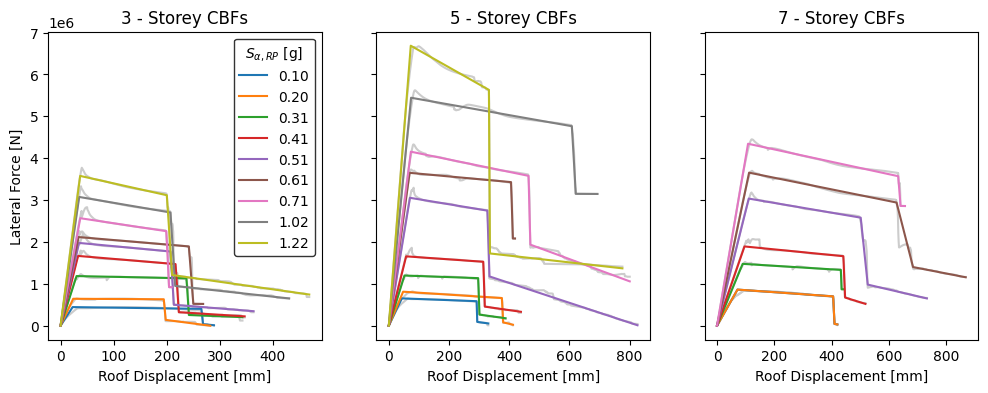

In [11]:
# Calculate the backbone curves
bbs = {b: fit_cbf_backbone(poc, cusum_drift=0.3, cusum_threshold=4) for b, poc in pocs.items()}

colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs, ns in zip([ax1, ax2, ax3], [three_s, five_s, seven_s], [3, 5, 7]):

    for b, colour in zip(bs[:], colours):
        # plot the po curve
        poc = pocs[b]
        bb = bbs[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(poc[:, 0], poc[:, 1], color="0.8", zorder=5)
        ax.plot(bb[:, 0], bb[:, 1], color=colour, label = f"{sa:.2f}", zorder=10)
   
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
legend = ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
frame = legend.get_frame()
frame.set_edgecolor("black")

### Database

In [12]:
# calculate all the backbone parameters and store as a dataframe
bb_params = {b: calculate_bb_params_from_fit(bb) for b, bb in bbs.items()}
bb_df = pd.DataFrame.from_dict(bb_params, orient="index")

# calculate some more params
bb_df["omega_fy"] = bb_df["fy"] / bdata_df["design_baseshear"]
bb_df["Wt"] = bdata_df["seismic_mass"] * 9.81
bb_df["Vb_coeff"] = bdata_df["design_baseshear"] / bb_df["Wt"]
bb_df["dy_drift"] = bb_df["dy"] / bdata_df["roof_height"]
bb_df["df_dy"] = bb_df["df"] / bb_df["dy"]
bb_df["ff_fy"] = bb_df["ff"] / bb_df["fy"]
bb_df["dr_dy"] = bb_df["dr"] / bb_df["dy"]
bb_df["dr_df"] = bb_df["dr"] / bb_df["df"]
bb_df["fr_fy"] = bb_df["fr"] / bb_df["fy"]
bb_df["fr_ff"] = bb_df["fr"] / bb_df["ff"]
bb_df["du_dy"] = bb_df["du"] / bb_df["dy"]
bb_df["fu_fy"] = bb_df["fu"] / bb_df["fy"]
bb_df["kpb_ke"] = bb_df["kpb"] / bb_df["ke"]
bb_df["kr_ke"] = bb_df["kr"] / bb_df["ke"]

In [13]:
bdata_df[["design_baseshear", "design_spectral_acceleration", "seismic_mass", "lambda", "design_period", "T_C"]]

,design_baseshear,design_spectral_acceleration,seismic_mass,lambda,design_period,T_C
name,,,,,,
3s_cbf_dc2_10,9.692758e+04,0.031657,312110.091743,1.00,0.708017,0.291607
3s_cbf_dc2_20,2.221441e+05,0.072553,312110.091743,1.00,0.614125,0.295885
3s_cbf_dc2_31,5.198243e+05,0.199738,312110.091743,0.85,0.510306,0.446928
3s_cbf_dc2_41,7.676999e+05,0.294982,312110.091743,0.85,0.452771,0.452437
3s_cbf_dc2_51,9.348288e+05,0.359200,312110.091743,0.85,0.432173,0.601125
3s_cbf_dc2_61,1.093226e+06,0.420063,312110.091743,0.85,0.415430,0.606959
3s_cbf_dc2_71,1.243458e+06,0.477788,312110.091743,0.85,0.401761,0.613065
3s_cbf_dc2_102,1.657291e+06,0.636800,312110.091743,0.85,0.367047,0.633945
3s_cbf_dc2_122,1.882640e+06,0.723388,312110.091743,0.85,0.351901,0.649233


In [14]:
bdata_df.columns

Index(['n_storeys', 'roof_height', 'V_wind_GQWSI_LC1', 'V_wind_GQWSI_LC2',
       'V_wind_GQWSI_LC3', 'T1_GQWSI_LC1', 'T1_GQWSI_LC2', 'T1_GQWSI_LC3',
       'gravity_frame_elastic_baseshear',
       'gravity_design_equivalent_seismic_baseshear', 'seismic_mass',
       'ductility_class', 'vertical_regularity', 'q_design', 'q_D', 'q_R',
       'q_S', 'q_max', 'design_period', 'design_spectral_acceleration',
       'design_baseshear', 'lambda', 'S_alpha_RP', 'S_beta_RP', 'S_alpha',
       'S_beta', 'T_beta', 'T_A', 'T_B', 'T_C', 'T_D', 'F_alpha', 'F_beta',
       'F_T', 'F_A', 'site_category', 'S_delta', 'delta',
       'seismic_action_class', 'seismic_F1', 'seismic_F2', 'seismic_F3',
       'seismic_F4', 'seismic_F5', 'seismic_F6', 'seismic_F7', 'seismic_V1',
       'seismic_V2', 'seismic_V3', 'seismic_V4', 'seismic_V5', 'seismic_V6',
       'seismic_V7'],
      dtype='object')

In [15]:
bb_df


,fy,dy,ff,df,fr,dr,fu,du,ke,kpb,...,df_dy,ff_fy,dr_dy,dr_df,fr_fy,fr_ff,du_dy,fu_fy,kpb_ke,kr_ke
3s_cbf_dc2_10,4.425869e+05,22.692958,4.009080e+05,265.242958,3.387419e+04,268.392958,8.903213e+03,288.867958,19503.270082,-171.836257,...,11.688338,0.905829,11.827148,1.011876,0.076537,0.084494,12.729410,0.020116,-0.008811,-0.062532
3s_cbf_dc2_20,6.413622e+05,23.756197,6.295588e+05,194.378697,1.370831e+05,198.053697,-2.442864e+03,282.053697,26997.680100,-69.178681,...,8.182231,0.981596,8.336928,1.018906,0.213737,0.217745,11.872847,-0.003809,-0.002562,-0.061525
3s_cbf_dc2_31,1.183706e+06,30.076321,1.130064e+06,237.051501,2.545307e+05,241.776501,2.021493e+05,342.576501,39356.751859,-259.170635,...,7.881666,0.954683,8.038766,1.019932,0.215029,0.225236,11.390240,0.170777,-0.006585,-0.013204
3s_cbf_dc2_41,1.664978e+06,32.994042,1.469673e+06,216.497898,3.210381e+05,222.797898,2.210402e+05,346.697898,50462.989199,-1064.311372,...,6.561727,0.882698,6.752671,1.029100,0.192818,0.218442,10.507894,0.132759,-0.021091,-0.015994
3s_cbf_dc2_51,1.975445e+06,34.715928,1.770508e+06,207.064295,4.978323e+05,213.364295,3.447437e+05,363.514295,56903.138664,-1189.087256,...,5.964533,0.896258,6.146006,1.030425,0.252010,0.281180,10.471110,0.174514,-0.020897,-0.017918
3s_cbf_dc2_61,2.115539e+06,33.879543,1.891562e+06,241.620654,5.207006e+05,250.020654,5.179911e+05,268.448154,62442.954336,-1078.154055,...,7.131757,0.894128,7.379694,1.034765,0.246131,0.275275,7.923606,0.244851,-0.017266,-0.002355
3s_cbf_dc2_71,2.565803e+06,37.056376,2.256132e+06,199.110269,9.185540e+05,204.360269,9.181045e+05,209.085269,69240.537735,-1910.917029,...,5.373172,0.879308,5.514848,1.026367,0.357999,0.407137,5.642356,0.357823,-0.027598,-0.001374
3s_cbf_dc2_102,3.073697e+06,35.082010,2.702402e+06,206.952889,9.475749e+05,215.877889,6.492162e+05,430.445389,87614.626340,-2160.316379,...,5.899117,0.879202,6.153521,1.043126,0.308285,0.350642,12.269690,0.211217,-0.024657,-0.015871
3s_cbf_dc2_122,3.576315e+06,36.870832,3.114983e+06,200.123969,1.208760e+06,210.098969,7.430408e+05,468.398969,96995.764581,-2825.864406,...,5.427704,0.871004,5.698243,1.049844,0.337990,0.388047,12.703781,0.207767,-0.029134,-0.018589
5s_cbf_dc2_10,6.508432e+05,43.373145,5.837935e+05,291.797197,8.861606e+04,293.897197,5.221238e+04,330.647197,15005.672546,-269.900044,...,6.727601,0.896980,6.776018,1.007197,0.136156,0.151793,7.623316,0.080223,-0.017987,-0.066013


Normalise the pushover curves by their fy and dy

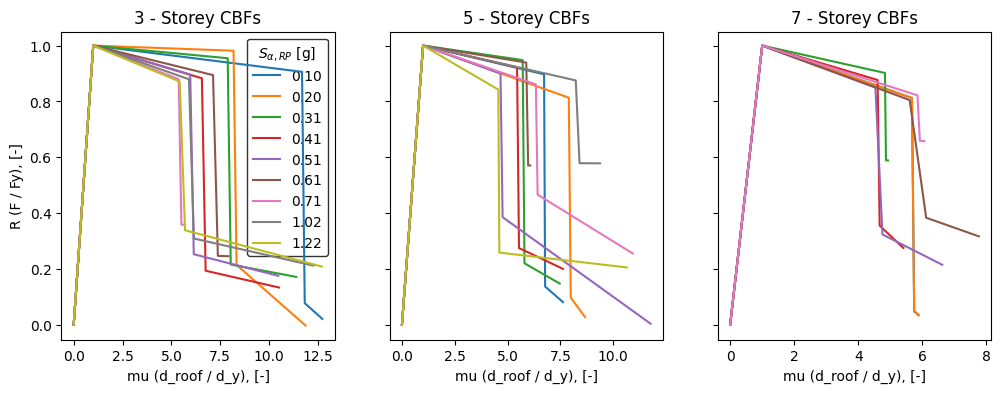

In [16]:
# Calculate the backbone curves
bbs_R_mu = {}
for b, bb in bbs.items():
    norm_bb = bb.copy()
    norm_bb[:, 0] /= bb_df.loc[b, "dy"]
    norm_bb[:, 1] /= bb_df.loc[b, "fy"]
    bbs_R_mu[b] = norm_bb

colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs, ns in zip([ax1, ax2, ax3], [three_s, five_s, seven_s], [3, 5, 7]):

    for b, colour in zip(bs[:], colours):
        # plot the po curve
        bb = bbs_R_mu[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(bb[:, 0], bb[:, 1], color=colour, label = f"{sa:.2f}", zorder=10)
   
    ax.set_xlabel("mu (d_roof / d_y), [-]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("R (F / Fy), [-]")
legend = ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
frame = legend.get_frame()
frame.set_edgecolor("black")

Normalise pushover curves by design force

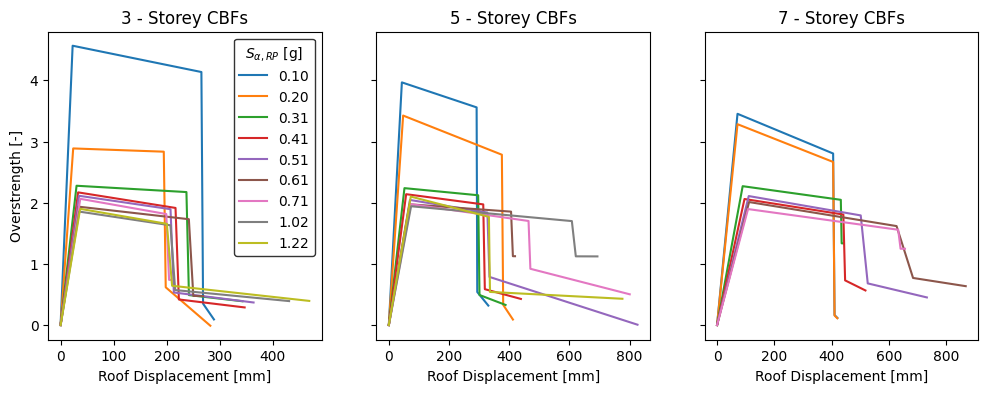

In [17]:
# Calculate the backbone curves
bbs_overstrength = {}
for b, bb in bbs.items():
    norm_bb = bb.copy()
    norm_bb[:, 1] /= bdata_df.loc[b, "design_baseshear"]
    bbs_overstrength[b] = norm_bb

colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs, ns in zip([ax1, ax2, ax3], [three_s, five_s, seven_s], [3, 5, 7]):

    for b, colour in zip(bs[:], colours):
        # plot the po curve
        bb = bbs_overstrength[b]
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(bb[:, 0], bb[:, 1], color=colour, label = f"{sa:.2f}", zorder=10)
   
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Overstrength [-]")
legend = ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
frame = legend.get_frame()
frame.set_edgecolor("black")

Plot some of the backbone parameters to investigate trends

In [18]:
# combine the building data and bb data into the same dataframes for investigation
df = pd.concat([bb_df, bdata_df], axis=1)
df

,fy,dy,ff,df,fr,dr,fu,du,ke,kpb,...,seismic_F5,seismic_F6,seismic_F7,seismic_V1,seismic_V2,seismic_V3,seismic_V4,seismic_V5,seismic_V6,seismic_V7
3s_cbf_dc2_10,4.425869e+05,22.692958,4.009080e+05,265.242958,3.387419e+04,268.392958,8.903213e+03,288.867958,19503.270082,-171.836257,...,NaN,NaN,NaN,17069.007996,51207.023987,9.692758e+04,NaN,NaN,NaN,NaN
3s_cbf_dc2_20,6.413622e+05,23.756197,6.295588e+05,194.378697,1.370831e+05,198.053697,-2.442864e+03,282.053697,26997.680100,-69.178681,...,NaN,NaN,NaN,39119.717226,117359.151677,2.221441e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_31,1.183706e+06,30.076321,1.130064e+06,237.051501,2.545307e+05,241.776501,2.021493e+05,342.576501,39356.751859,-259.170635,...,NaN,NaN,NaN,91541.379705,274624.139115,5.198243e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_41,1.664978e+06,32.994042,1.469673e+06,216.497898,3.210381e+05,222.797898,2.210402e+05,346.697898,50462.989199,-1064.311372,...,NaN,NaN,NaN,135192.440416,405577.321247,7.676999e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_51,1.975445e+06,34.715928,1.770508e+06,207.064295,4.978323e+05,213.364295,3.447437e+05,363.514295,56903.138664,-1189.087256,...,NaN,NaN,NaN,164623.935396,493871.806189,9.348288e+05,NaN,NaN,NaN,NaN
3s_cbf_dc2_61,2.115539e+06,33.879543,1.891562e+06,241.620654,5.207006e+05,250.020654,5.179911e+05,268.448154,62442.954336,-1078.154055,...,NaN,NaN,NaN,192517.767849,577553.303547,1.093226e+06,NaN,NaN,NaN,NaN
3s_cbf_dc2_71,2.565803e+06,37.056376,2.256132e+06,199.110269,9.185540e+05,204.360269,9.181045e+05,209.085269,69240.537735,-1910.917029,...,NaN,NaN,NaN,218973.773887,656921.321660,1.243458e+06,NaN,NaN,NaN,NaN
3s_cbf_dc2_102,3.073697e+06,35.082010,2.702402e+06,206.952889,9.475749e+05,215.877889,6.492162e+05,430.445389,87614.626340,-2160.316379,...,NaN,NaN,NaN,291850.005736,875550.017208,1.657291e+06,NaN,NaN,NaN,NaN
3s_cbf_dc2_122,3.576315e+06,36.870832,3.114983e+06,200.123969,1.208760e+06,210.098969,7.430408e+05,468.398969,96995.764581,-2825.864406,...,NaN,NaN,NaN,331534.014792,994602.044377,1.882640e+06,NaN,NaN,NaN,NaN
5s_cbf_dc2_10,6.508432e+05,43.373145,5.837935e+05,291.797197,8.861606e+04,293.897197,5.221238e+04,330.647197,15005.672546,-269.900044,...,50638.472915,NaN,NaN,11343.017933,34029.053799,6.805811e+04,1.134302e+05,1.640687e+05,NaN,NaN


### Fitting Dy

Fit for # Storeys = 3
                            OLS Regression Results                            
Dep. Variable:               dy_drift   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     25.37
Date:                Tue, 12 May 2026   Prob (F-statistic):            0.00150
Time:                        09:08:18   Log-Likelihood:                 62.891
No. Observations:                   9   AIC:                            -121.8
Df Residuals:                       7   BIC:                            -121.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.0

c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
C:\Users\clemettn\AppData\Local\Temp\ipykernel_77636\753656007.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

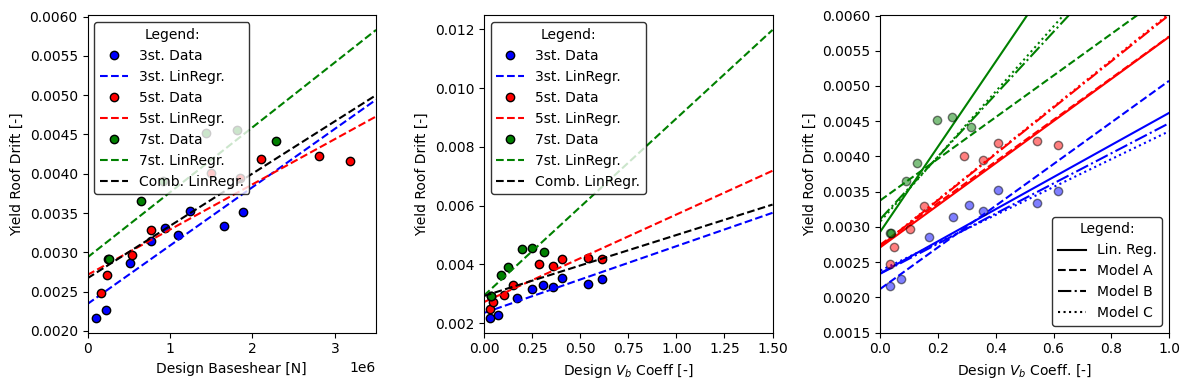

In [19]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4))

# ax1: dy values normalised by roof displacement against design base shear
x_min = 0
x_max = 3.5e6

dy_regressions = {}
for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = df[df["n_storeys"] == ns]

    # do a regression fit
    x = sub_df["design_baseshear"]
    y = sub_df["dy_drift"]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax1.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"{ns}st. Data")
    ax1.plot(rx, ry, ls="--", color=colour, label=f"{ns}st. LinRegr.")

    dy_regressions[ns] = rmodel

x = df["design_baseshear"]
y = df["dy_drift"]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax1.plot(rx, ry, ls="--", color="k", label=f"Comb. LinRegr.")
dy_regressions["total"] = rmodel

leg = ax1.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax1.set_xlim(x_min, x_max)
ax1.set_xlabel("Design Baseshear [N]")
ax1.set_ylabel("Yield Roof Drift [-]")

# # ax2: dy values normalised by roof displacement against design Vbcoeff
x_min = 0
x_max = 1.5

dy_regressions = {}
for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = df[df["roof_height"] == ns*3500]

    # do a regression fit
    x = sub_df["Vb_coeff"]
    y = sub_df["dy_drift"]
    X = sm.add_constant(x)
    model0 = sm.OLS(y, X).fit()
    print(f"Fit for # Storeys = {ns}")
    print(model0.summary())
    print()

    rx = np.linspace(x_min, x_max)
    ry = model0.params["Vb_coeff"] * rx + model0.params["const"]

    ax2.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"{ns}st. Data")
    ax2.plot(rx, ry, ls="--", color=colour, label=f"{ns}st. LinRegr.")
    
    # also plot on ax3 to compare to multlinear fits
    ax3.plot(rx, ry, ls="-", color=colour, label=f"{ns}st. LinRegr.")

    dy_regressions[ns] = rmodel

x = df["Vb_coeff"]
y = df["dy_drift"]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax2.plot(rx, ry, ls="--", color="k", label=f"Comb. LinRegr.")
dy_regressions["total"] = rmodel

leg = ax2.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax2.set_xlim(x_min, x_max)
ax2.set_xlabel("Design $V_b$ Coeff [-]")
ax2.set_ylabel("Yield Roof Drift [-]")

# ax3: compare some multilinear fits
# only storeys and SA
Y = df["dy_drift"]
X = df[["roof_height", "Vb_coeff"]]
X["roof_height"] = X["roof_height"] / 1000    # in m
X = sm.add_constant(X)
dy_modelA = sm.OLS(Y, X).fit()
print("FIT:: MODEL 1")
print(dy_modelA.summary())
print()

# storeys, SA and SA * storeys
Y = df["dy_drift"]
X = df[["roof_height", "Vb_coeff"]].copy()
X["roof_height"] = X["roof_height"] / 1000    # in m
X["rh_x_Vbc"] = df["roof_height"] / 1000 * df["Vb_coeff"]
X = sm.add_constant(X)
dy_modelB = sm.OLS(Y, X).fit()
print("FIT:: MODEL 2")
print(dy_modelB.summary())
print()

# storeys, and SA * storeys
Y = df["dy_drift"]
X = df[["roof_height"]].copy()
X["roof_height"] = X["roof_height"] / 1000    # in m
X["rh_x_Vbc"] = df["roof_height"] / 1000 * df["Vb_coeff"]
X = sm.add_constant(X)
dy_modelC = sm.OLS(Y, X).fit()
print("FIT:: MODEL 3")
print(dy_modelC.summary())
print()

x1 = np.linspace(0, 1.0)    # spectral acceleration
x2s = np.array([3, 5, 7]) * 3.5                      # building height in m
for x2, colour in zip(x2s, ["b", "r", "g"]):

    sub_df = df[df["roof_height"] / 1000 == x2]
    # do a regression fit
    x = sub_df["Vb_coeff"]
    y = sub_df["dy_drift"]
    ax3.plot(x, y, ls="", marker="o", mfc=colour, mec="k", alpha=0.5)
    
    yfit1 = dy_modelA.params["Vb_coeff"] * x1 + dy_modelA.params["roof_height"] * x2 + dy_modelA.params["const"]
    ax3.plot(x1, yfit1, color=colour, ls="--")

    x3 = x1 * x2
    yfit2 = dy_modelB.params["Vb_coeff"] * x1 + \
            dy_modelB.params["roof_height"] * x2 + \
            dy_modelB.params["rh_x_Vbc"] * x3 + \
            dy_modelB.params["const"]
    ax3.plot(x1, yfit2, color=colour, ls="-.")

    yfit3 = dy_modelC.params["roof_height"] * x2 + \
            dy_modelC.params["rh_x_Vbc"] * x3 + \
            dy_modelC.params["const"]
    ax3.plot(x1, yfit3, color=colour, ls=":")


handles = [
    Line2D([], [], color="k", label="Lin. Reg.", linestyle="-"), 
    Line2D([], [], color="k", label="Model A", linestyle="--"), 
    Line2D([], [], color="k", label="Model B", linestyle="-."), 
    Line2D([], [], color="k", label="Model C", linestyle=":"), 
    
]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
leg = ax3.legend(handles=handles, 
           title="Legend:",
           frameon=True)

frame = leg.get_frame()
frame.set_edgecolor("k")
ax3.set_xlim(x_min, 1.0)
ax3.set_ylim(0.0015, 0.006)
ax3.set_xlabel("Design $V_b$ Coeff. [-]")
ax3.set_ylabel("Yield Roof Drift [-]")

fig.tight_layout()

predictions vs. data

const          0.000063
roof_height    0.008156
Vb_coeff       0.726679
rh_x_Vbc       0.034367
dtype: float64


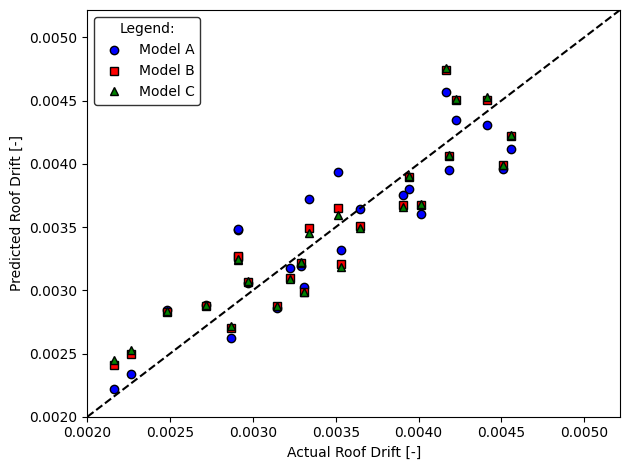

In [20]:
pred_model_1 = dy_modelA.params["Vb_coeff"] * df["Vb_coeff"] + \
                dy_modelA.params["roof_height"] * df["roof_height"] / 1000 + \
                dy_modelA.params["const"]

pred_model_2 = dy_modelB.params["Vb_coeff"] * df["Vb_coeff"] + \
                dy_modelB.params["roof_height"] * df["roof_height"] / 1000 + \
                dy_modelB.params["rh_x_Vbc"] * (df["Vb_coeff"] * df["roof_height"] / 1000)+ \
                dy_modelB.params["const"]

pred_model_3 =  dy_modelC.params["roof_height"] * df["roof_height"] / 1000 + \
                dy_modelC.params["rh_x_Vbc"] * (df["Vb_coeff"] * df["roof_height"] / 1000)+ \
                dy_modelC.params["const"]

actual = df["dy_drift"]

xmin = ymin = 0.002
xmax = ymax = max(np.concat([pred_model_1, pred_model_2, actual])) * 1.1

fig, ax = plt.subplots()
ax.plot(actual, pred_model_1, ls="", marker="o", mec="k", mfc="b", label="Model A")
ax.plot(actual, pred_model_2, ls="", marker="s", mec="k", mfc="r", label="Model B")
ax.plot(actual, pred_model_3, ls="", marker="^", mec="k", mfc="g", label="Model C")
ax.plot([xmin, xmax], [ymin, ymax], "--k")

leg = ax.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Actual Roof Drift [-]")
ax.set_ylabel("Predicted Roof Drift [-]")

fig.tight_layout()

print(dy_modelB.pvalues)

In [21]:
dy_params = dy_modelC.params
print(dy_params)

const          0.001858
roof_height    0.000050
rh_x_Vbc       0.000188
dtype: float64


### Fitting Fy

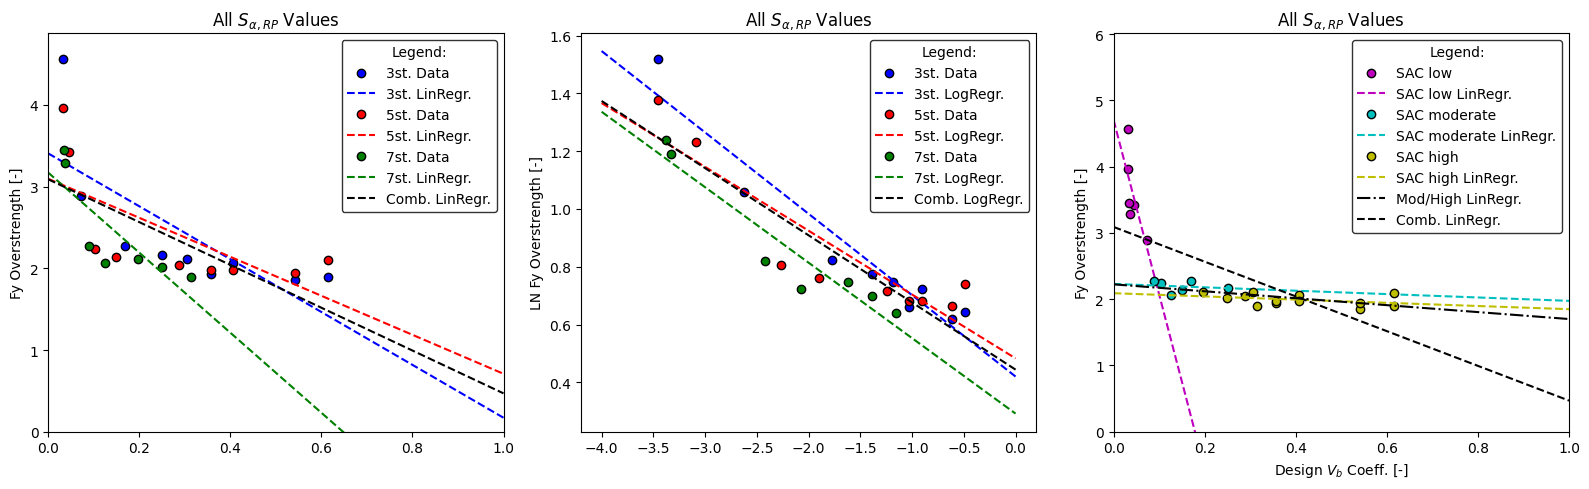

In [22]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(16, 5))

# ax1: fy values normalised by design base shear all buildings
x_min = 0
x_max = 1.0

for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = df[df["n_storeys"] == ns]

    # do a regression fit
    # x = sub_df["design_spectral_acceleration"]
    x = sub_df["Vb_coeff"]
    y = sub_df["omega_fy"]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax1.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"{ns}st. Data")
    ax1.plot(rx, ry, ls="--", color=colour, label=f"{ns}st. LinRegr.")

# x = df["design_spectral_acceleration"]
x = df["Vb_coeff"]
y = df["omega_fy"]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax1.plot(rx, ry, ls="--", color="k", label=f"Comb. LinRegr.")

leg = ax1.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(0)
# ax1.set_xlabel("Design $S_a$ [g]")
ax3.set_xlabel("Design $V_b$ Coeff. [-]")
ax1.set_ylabel("Fy Overstrength [-]")
ax1.set_title(r"All $S_{\alpha,RP}$ Values")

# ax2: fy values normalised by design base shear - all buildings with S_alpha

x_min = -4
x_max = np.log(1.0)

for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = df[df["n_storeys"] == ns]

    # do a regression fit
    # x = np.log(sub_df["design_spectral_acceleration"])
    x = np.log(sub_df["Vb_coeff"])
    y = np.log(sub_df["omega_fy"])
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax2.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"{ns}st. Data")
    ax2.plot(rx, ry, ls="--", color=colour, label=f"{ns}st. LogRegr.")

# x = np.log(df["design_spectral_acceleration"])
x = np.log(df["Vb_coeff"])
y = np.log(df["omega_fy"])
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax2.plot(rx, ry, ls="--", color="k", label=f"Comb. LogRegr.")
dy_regressions["total"] = rmodel

leg = ax2.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
# ax2.set_xlim(x_min, x_max)
# ax2.set_ylim(0)
# ax2.set_xlabel("LN Design $S_a$ [g]")
ax3.set_xlabel("LN Design $V_b$ Coeff. [-]")
ax2.set_ylabel("LN Fy Overstrength [-]")
ax2.set_title(r"All $S_{\alpha,RP}$ Values")


# ax3: fy values normalised by design base shear - Split Low / Moderate / High Seismicity index

x_min = 0
x_max = 1.0

fy_regressions = {}
for sac, colour in zip(df["seismic_action_class"].unique(), ["m", "c", "y"]):
    sub_df = df[df["seismic_action_class"] == sac]

    # do a regression fit
    # x = sub_df["design_spectral_acceleration"]
    x = sub_df["Vb_coeff"]
    y = sub_df["omega_fy"]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax3.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"SAC {sac}")
    ax3.plot(rx, ry, ls="--", color=colour, label=f"SAC {sac} LinRegr.")

    fy_regressions[sac] = rmodel

sub_df_mod_high = df[(df["seismic_action_class"] == "moderate") |
            (df["seismic_action_class"] == "high")]
# x = sub_df["design_spectral_acceleration"]
x = sub_df_mod_high["Vb_coeff"]
y = sub_df_mod_high["omega_fy"]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax3.plot(rx, ry, ls="-.", color="k", label=f"Mod/High LinRegr.")
fy_regressions["mod/high"] = rmodel

# x = sub_df["design_spectral_acceleration"]
x = df["Vb_coeff"]
y = df["omega_fy"]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax3.plot(rx, ry, ls="--", color="k", label=f"Comb. LinRegr.")
fy_regressions["total"] = rmodel

leg = ax3.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(0)
# ax3.set_xlabel("Design $S_a$ [g]")
ax3.set_xlabel("Design $V_b$ Coeff. [-]")
ax3.set_ylabel("Fy Overstrength [-]")
ax3.set_title(r"All $S_{\alpha,RP}$ Values")
fig.tight_layout()

In [23]:
## SAC Low
fy_params_mod_high = pd.Series({
    "Vb_coeff": fy_regressions["mod/high"].slope,
    "const": fy_regressions["mod/high"].intercept}) 

fy_params_low = pd.Series({
    "Vb_coeff": fy_regressions["low"].slope,
    "const": fy_regressions["low"].intercept}) 

print(fy_params_low)
print()
print(fy_params_mod_high)

Vb_coeff   -26.327444
const        4.701270
dtype: float64

Vb_coeff   -0.523401
const       2.223880
dtype: float64


### Fitting Df

6.253894857647513 1.590260947609986


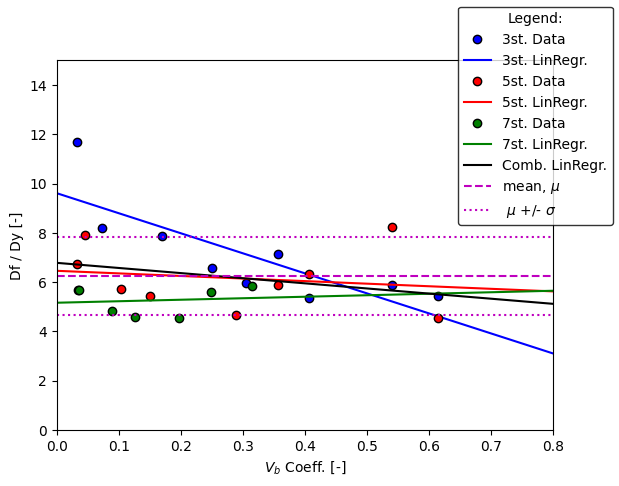

In [24]:
fig, ax1 = plt.subplots()

# ax1: dy values normalised by roof displacement against design base shear
x_min = 0
x_max = 0.8

for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = df[df["n_storeys"] == ns]

    # do a regression fit
    x = sub_df["Vb_coeff"]
    y = sub_df["df_dy"]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax1.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"{ns}st. Data")
    ax1.plot(rx, ry, ls="-", color=colour, label=f"{ns}st. LinRegr.")


x = df["Vb_coeff"]
y = df["df_dy"]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax1.plot(rx, ry, ls="-", color="k", label=f"Comb. LinRegr.")

mean = df["df_dy"].mean()
std = df["df_dy"].std()
ax1.plot([x_min, x_max], [mean, mean], ls="--", color="m", label=r"mean, $\mu$")
ax1.plot([x_min, x_max], [mean + std, mean + std], ls=":", color="m", label=r" $\mu$ +/- $\sigma$")
ax1.plot([x_min, x_max], [mean - std, mean - std], ls=":", color="m")

leg = fig.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(0, 15)
ax1.set_xlabel("$V_b$ Coeff. [-]")
ax1.set_ylabel("Df / Dy [-]")

print(mean, std)
df_mean = mean

In [25]:
df_params = pd.Series({"const": df_mean})

print(df_params)

const    6.253895
dtype: float64


### Fitting Ff

0.8808315247819675 0.04729581506346321


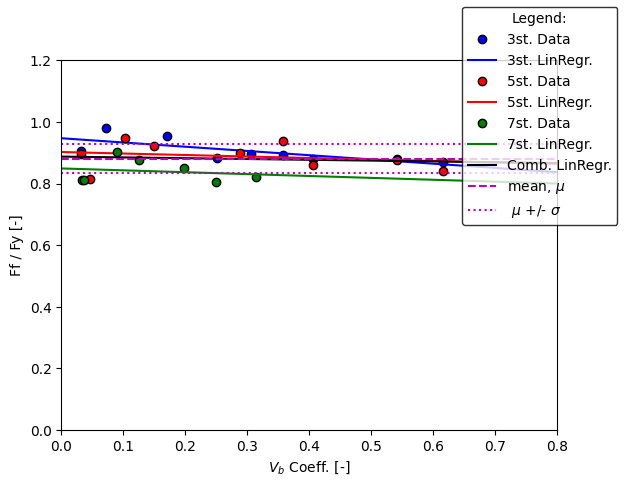

In [26]:
fig, ax1 = plt.subplots()

# ax1: Ff values normalised by Fy
x_min = 0
x_max = 0.8

x_var = "ff_fy"

for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = df[df["n_storeys"] == ns]

    # do a regression fit
    x = sub_df["Vb_coeff"]
    y = sub_df[x_var]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax1.plot(x, y, ls="", marker="o", mfc=colour, mec="k", label=f"{ns}st. Data")
    ax1.plot(rx, ry, ls="-", color=colour, label=f"{ns}st. LinRegr.")

x = df["Vb_coeff"]
y = df[x_var]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax1.plot(rx, ry, ls="-", color="k", label=f"Comb. LinRegr.")

mean = df[x_var].mean()
std = df[x_var].std()
ax1.plot([x_min, x_max], [mean, mean], ls="--", color="m", label=r"mean, $\mu$")
ax1.plot([x_min, x_max], [mean + std, mean + std], ls=":", color="m", label=r" $\mu$ +/- $\sigma$")
ax1.plot([x_min, x_max], [mean - std, mean - std], ls=":", color="m")

leg = fig.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(0, 1.2)
ax1.set_xlabel("$V_b$ Coeff. [-]")
ax1.set_ylabel("Ff / Fy [-]")

print(mean, std)
ff_mean = mean


In [27]:
ff_params = pd.Series({"const": ff_mean})

print(ff_params)

const    0.880832
dtype: float64


### Fitting Dr and Fr

Due to the numerical instability in the analysis some of the residual branches are very short and it is not clear if the structure reached the end of the fracture fall or not.
For this reason we will only consider the subset of buildings that don't have very short residual branches and the regression. Additionall 7s_61 is not considered for Dr as it is clearly an outlier when the pushover curves are compared with each other

FIT:: MODEL 1
                            OLS Regression Results                            
Dep. Variable:                  fr_fy   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     4.424
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0516
Time:                        09:08:19   Log-Likelihood:                 14.142
No. Observations:                  18   AIC:                            -24.28
Df Residuals:                      16   BIC:                            -22.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2041      0.046      

c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


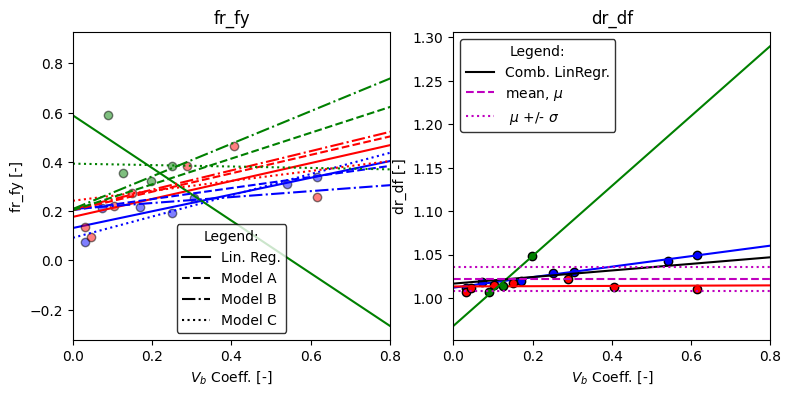

In [28]:
subset = [
    "3s_cbf_dc2_10",
    "3s_cbf_dc2_20",
    "3s_cbf_dc2_31",
    "3s_cbf_dc2_41",
    "3s_cbf_dc2_51",
    "3s_cbf_dc2_102",
    "3s_cbf_dc2_122",
    "5s_cbf_dc2_10",
    "5s_cbf_dc2_20",
    "5s_cbf_dc2_31",
    "5s_cbf_dc2_41",
    "5s_cbf_dc2_51",
    "5s_cbf_dc2_71",
    "5s_cbf_dc2_122",
    "7s_cbf_dc2_31",
    "7s_cbf_dc2_41",
    "7s_cbf_dc2_51",
    "7s_cbf_dc2_61",
]

ss_df = df.loc[subset, :]

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(9,4))

# ax1: Fr values normalised by Fy
x_min = 0
x_max = 0.8

y_var = "fr_fy"

# SA * storeys
Y = ss_df[y_var]
X = pd.DataFrame({"rh_x_Vbc":ss_df["roof_height"] / 1000 * ss_df["Vb_coeff"]})
X = sm.add_constant(X)
fr_modelA = sm.OLS(Y, X).fit()
print("FIT:: MODEL 1")
print(fr_modelA.summary())
print("\np-values:")
print(fr_modelA.pvalues)
print()

# SA and SA * storeys
Y = ss_df[y_var]
X = ss_df[["Vb_coeff"]].copy()
X["rh_x_Vbc"] = ss_df["roof_height"] / 1000 * ss_df["Vb_coeff"]
X = sm.add_constant(X)
fr_modelB = sm.OLS(Y, X).fit()
print("FIT:: MODEL 2")
print(fr_modelB.summary())
print("\np-values:")
print(fr_modelB.pvalues)
print()

# storeys, SA and SA * storeys
Y = ss_df[y_var]
X = ss_df[["roof_height", "Vb_coeff"]].copy()
X["roof_height"] = X["roof_height"] / 1000    # in m
X["rh_x_Vbc"] = ss_df["roof_height"] / 1000 * ss_df["Vb_coeff"]
X = sm.add_constant(X)
fr_modelC = sm.OLS(Y, X).fit()
print("FIT:: MODEL 3")
print(fr_modelC.summary())
print("\np-values:")
print(fr_modelC.pvalues)
print()

x1 = np.linspace(0, 1.0)            # spectral acceleration
x2s = np.array([3, 5, 7]) * 3.5     # building height in m

for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = ss_df[ss_df["n_storeys"] == ns]

    # do a regression fit
    x = sub_df["Vb_coeff"]
    y = sub_df[y_var]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax1.plot(x, y, ls="", marker="o", mfc=colour, mec="k", alpha=0.5)
    ax1.plot(rx, ry, ls="-", color=colour, label=f"{ns}st. LinRegr.")

for x2, colour in zip(x2s, ["b", "r", "g"]):
    x3 = x1 * x2
    
    yfit1 = fr_modelA.params["rh_x_Vbc"] * x3 + \
            fr_modelA.params["const"]
    ax1.plot(x1, yfit1, color=colour, ls="--")
    
    yfit2 = fr_modelB.params["Vb_coeff"] * x1 + \
            fr_modelB.params["rh_x_Vbc"] * x3 + \
            fr_modelB.params["const"]
    ax1.plot(x1, yfit2, color=colour, ls="-.")
    
    yfit3 = fr_modelC.params["Vb_coeff"] * x1 + \
            fr_modelC.params["roof_height"] * x2 + \
            fr_modelC.params["rh_x_Vbc"] * x3 + \
            fr_modelC.params["const"]
    ax1.plot(x1, yfit3, color=colour, ls=":")

ax1.set_xlim(x_min, x_max)
ax1.set_xlabel("$V_b$ Coeff. [-]")
ax1.set_ylabel(f"{y_var} [-]")
ax1.set_title(f"{y_var}")

handles = [
    Line2D([], [], color="k", label="Lin. Reg.", linestyle="-"), 
    Line2D([], [], color="k", label="Model A", linestyle="--"), 
    Line2D([], [], color="k", label="Model B", linestyle="-."), 
    Line2D([], [], color="k", label="Model C", linestyle=":"), 
    
]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
leg = ax1.legend(handles=handles, 
           title="Legend:",
           frameon=True)

frame = leg.get_frame()
frame.set_edgecolor("k")

################################################################################
# Ax2
################################################################################
ss_df2 = ss_df.drop(index="7s_cbf_dc2_61")

x_min = 0
x_max = 0.8

y_var = "dr_df"

# # SA and SA * storeys
# Y = ss_df[y_var]
# X = ss_df[["Vb_coeff"]].copy()
# X["roof_height"] = ss_df["roof_height"] / 1000
# X = sm.add_constant(X)
# dr_modelB = sm.OLS(Y, X).fit()
# print("FIT:: MODEL B")
# print(dr_modelB.summary())
# print("\np-values:")
# print(dr_modelB.pvalues)
# print()

# # storeys, SA and SA * storeys
# Y = ss_df[y_var]
# X = ss_df[["roof_height", "Vb_coeff"]].copy()
# X["roof_height"] = X["roof_height"] / 1000    # in m
# X["rh_x_Vbc"] = ss_df["roof_height"] / 1000 * ss_df["Vb_coeff"]
# X = sm.add_constant(X)
# dr_modelC = sm.OLS(Y, X).fit()
# print("FIT:: MODEL C")
# print(dr_modelC.summary())
# print("\np-values:")
# print(dr_modelC.pvalues)
# print()

for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = ss_df2[ss_df2["n_storeys"] == ns]

    # do a regression fit
    x = sub_df["Vb_coeff"]
    y = sub_df[y_var]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax2.plot(x, y, ls="", marker="o", mfc=colour, mec="k")
    ax2.plot(rx, ry, ls="-", color=colour)

    dy_regressions[ns] = rmodel

for x2, colour in zip(x2s, ["b", "r", "g"]):
    x3 = x1 * x2
    
    # yfit1 = dr_modelA.params["rh_x_Vbc"] * x3 + \
    #         dr_modelA.params["const"]
    # ax2.plot(x1, yfit1, color=colour, ls="--")
    
    # yfit2 = dr_modelB.params["Vb_coeff"] * x1 + \
    #         dr_modelB.params["roof_height"] * x2 + \
    #         dr_modelB.params["const"]
    # ax2.plot(x1, yfit2, color=colour, ls="-.")
    
    # yfit3 = dr_modelC.params["Vb_coeff"] * x1 + \
    #         dr_modelC.params["roof_height"] * x2 + \
    #         dr_modelC.params["rh_x_Vbc"] * x3 + \
    #         dr_modelC.params["const"]
    # ax2.plot(x1, yfit3, color=colour, ls=":")

x = ss_df["Vb_coeff"]
y = ss_df[y_var]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax2.plot(rx, ry, ls="-", color="k", label=f"Comb. LinRegr.")

mean = ss_df2[y_var].mean()
std = ss_df2[y_var].std()
ax2.plot([x_min, x_max], [mean, mean], ls="--", color="m", label=r"mean, $\mu$")
ax2.plot([x_min, x_max], [mean + std, mean + std], ls=":", color="m", label=r" $\mu$ +/- $\sigma$")
ax2.plot([x_min, x_max], [mean - std, mean - std], ls=":", color="m")

leg = ax2.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
ax2.set_xlim(x_min, x_max)
# ax2.set_ylim(0, 15)
ax2.set_xlabel("$V_b$ Coeff. [-]")
ax2.set_ylabel(f"{y_var} [-]")
ax2.set_title(f"{y_var}")

print(f"Mean Dr: {mean}", f"Sigma Dr: {std}")
dr_df_mean = mean

Fr model --> Model B and Dr model --> mean

In [29]:
fr_params = fr_modelB.params
dr_params = pd.Series({"const": dr_df_mean})

print(fr_params)
print()
print(dr_params)

const       0.208905
Vb_coeff   -0.285167
rh_x_Vbc    0.038660
dtype: float64

const    1.021658
dtype: float64


### Fitting Du and Fu

Due to the numerical instability in the analysis they length of the residual (after fracture) branch varies significantly, however the slope looks to be quite constant. For this reason we will consider the subset of buildings that do not have very short residual branches and the regression will be done on this slope rather than the point (Fu, Du)

FIT:: MODEL 2
                            OLS Regression Results                            
Dep. Variable:                  kr_ke   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     4.073
Date:                Tue, 12 May 2026   Prob (F-statistic):             0.0387
Time:                        09:08:20   Log-Likelihood:                 41.722
No. Observations:                  18   AIC:                            -77.44
Df Residuals:                      15   BIC:                            -74.77
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0609      0.028   

c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\clemettn\Documents\phd\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


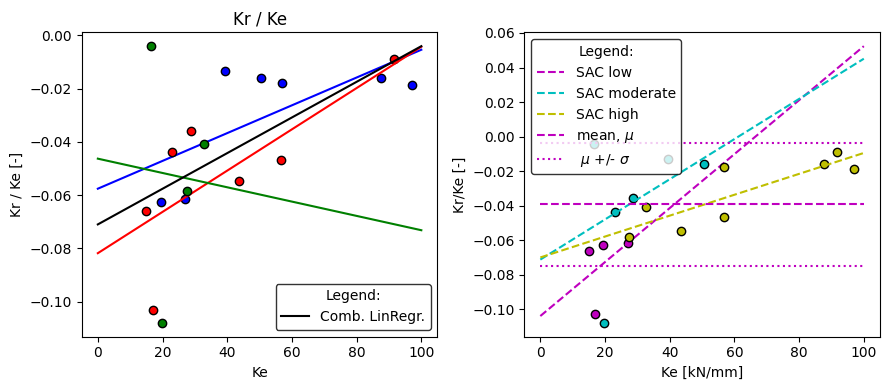

In [30]:
subset = [
    "3s_cbf_dc2_10",
    "3s_cbf_dc2_20",
    "3s_cbf_dc2_31",
    "3s_cbf_dc2_41",
    "3s_cbf_dc2_51",
    "3s_cbf_dc2_102",
    "3s_cbf_dc2_122",
    "5s_cbf_dc2_10",
    "5s_cbf_dc2_20",
    "5s_cbf_dc2_31",
    "5s_cbf_dc2_41",
    "5s_cbf_dc2_51",
    "5s_cbf_dc2_71",
    "5s_cbf_dc2_122",
    "7s_cbf_dc2_31",
    "7s_cbf_dc2_41",
    "7s_cbf_dc2_51",
    "7s_cbf_dc2_61",
]

ss_df = df.loc[subset, :]


fig, [ax1, ax2] = plt.subplots(1, 2, figsize=[9, 4])
x_min = 0
x_max = 100

y_var = "kr_ke"

# height, ke
Y = ss_df[y_var]
X = ss_df[["ke"]].copy() / 1e3
X["roof_height"] = ss_df["roof_height"] / 1000    # in m
X = sm.add_constant(X)
modelB = sm.OLS(Y, X).fit()
print("FIT:: MODEL 2")
print(modelB.summary())
print("\np-values:")
print(modelB.pvalues)
print()

# height, ke and ke * height
Y = ss_df[y_var]
X = ss_df[["ke"]].copy() / 1e3
X["roof_height"] = ss_df["roof_height"] / 1000    # in m
X["rh_x_ke"] = ss_df["roof_height"] / 1000 * ss_df["ke"] / 1000
X = sm.add_constant(X)
modelC = sm.OLS(Y, X).fit()
print("FIT:: MODEL 3")
print(modelC.summary())
print("\np-values:")
print(modelC.pvalues)
print()


for ns, colour in zip([3, 5, 7], ["b", "r", "g"]):
    sub_df = ss_df[ss_df["n_storeys"] == ns]

#     # do a regression fit
    x = sub_df["ke"] / 1000
    y = sub_df[y_var]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept
    print(f"{ns} St. R² = {rmodel.rvalue ** 2}")
    ax1.plot(x, y, ls="", marker="o", mfc=colour, mec="k")
    ax1.plot(rx, ry, ls="-", color=colour)

x1 = np.linspace(0, 100)            # spectral acceleration
x2s = np.array([3, 5, 7]) * 3.5     # building height in m

for x2, colour in zip(x2s, ["b", "r", "g"]):
    x3 = x1 * x2
    
    # yfit1 = modelA.params["rh_x_SA"] * x3 + \
    #         modelA.params["const"]
    # ax.plot(x1, yfit1, color=colour, ls="--")
    
    # yfit2 = modelB.params["ke"] * x1 + \
    #         modelB.params["roof_height"] * x2 + \
    #         modelB.params["const"]
    # ax.plot(x1, yfit2, color=colour, ls="-.")
    
    # yfit3 = modelC.params["ke"] * x1 + \
    #         modelC.params["roof_height"] * x2 + \
    #         modelC.params["rh_x_ke"] * x3 + \
    #         modelC.params["const"]
    # ax.plot(x1, yfit3, color=colour, ls=":")

    ...


x = ss_df["ke"] / 1000
y = ss_df[y_var]
rmodel = linregress(x, y)
rx = np.linspace(x_min, x_max)
ry = rmodel.slope * rx + rmodel.intercept
ax1.plot(rx, ry, ls="-", color="k", label=f"Comb. LinRegr.")
print(f"All R² = {rmodel.rvalue ** 2}")

leg = ax1.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
# ax.set_xlim(x_min, x_max)
# ax.set_ylim(0, 15)
ax1.set_xlabel("Ke")
ax1.set_ylabel("Kr / Ke [-]")
ax1.set_title("Kr / Ke")

kr_model = rmodel


###############################################################################
## AX2 : Looking at SAC
###############################################################################

kr_regressions = {}
for sac, colour in zip(ss_df["seismic_action_class"].unique(), ["m", "c", "y"]):
    sub_df = ss_df[ss_df["seismic_action_class"] == sac]

    # do a regression fit
    x = sub_df["ke"] / 1000
    y = sub_df["kr_ke"]
    rmodel = linregress(x, y)

    rx = np.linspace(x_min, x_max)
    ry = rmodel.slope * rx + rmodel.intercept

    ax2.plot(x, y, ls="", marker="o", mfc=colour, mec="k")
    ax2.plot(rx, ry, ls="--", color=colour, label=f"SAC {sac}")

    kr_regressions[sac] = rmodel

# sub_df = df[(df["seismic_action_class"] == "moderate") |
#             (df["seismic_action_class"] == "high")]
# x = sub_df["design_spectral_acceleration"]
# y = sub_df["omega_fy"]
# rmodel = linregress(x, y)
# rx = np.linspace(x_min, x_max)
# ry = rmodel.slope * rx + rmodel.intercept
# ax3.plot(rx, ry, ls="-.", color="k", label=f"Mod/High LinRegr.")
# fy_regressions["mod/high"] = rmodel

# x = df["design_spectral_acceleration"]
# y = df["omega_fy"]
# rmodel = linregress(x, y)
# rx = np.linspace(x_min, x_max)
# ry = rmodel.slope * rx + rmodel.intercept
# ax3.plot(rx, ry, ls="--", color="k", label=f"Comb. LinRegr.")
# fy_regressions["total"] = rmodel

mean = df[y_var].mean()
std = df[y_var].std()
ax2.plot([x_min, x_max], [mean, mean], ls="--", color="m", label=r"mean, $\mu$")
ax2.plot([x_min, x_max], [mean + std, mean + std], ls=":", color="m", label=r" $\mu$ +/- $\sigma$")
ax2.plot([x_min, x_max], [mean - std, mean - std], ls=":", color="m")


leg = ax2.legend(title="Legend:")
frame = leg.get_frame()
frame.set_edgecolor("k")
# ax2.set_xlim(x_min, x_max)
# ax2.set_ylim(0)
ax2.set_xlabel("Ke [kN/mm]")
ax2.set_ylabel("Kr/Ke [-]")
ax2.set_title(r"")
fig.tight_layout()

kr_ke_mean = mean


No other obvious trend with seismic action index

Choose mean value. If the regression is used then for some of the stiffer structures a positive slope comes out. This isn't what we want.
Using the average value is rough approximation.

In [31]:
kr_ke_params = pd.Series({"const": kr_ke_mean})
print(kr_ke_params)

const   -0.039326
dtype: float64


### Summary of the fits

In [32]:
fit_params = [dy_params, fy_params_low, fy_params_mod_high, df_params, ff_params, dr_params, fr_params, kr_ke_params]
fit_params = pd.DataFrame(fit_params).T.fillna(0)
fit_params.columns = ["dy", "wy_lw", "wy_mh", "mu_f", "ff_fy", "dr_df", "fr_fy", "kr_ke"]
fit_params.index = ["0", "h", "hVbc", "Vbc"]
fit_params

,dy,wy_lw,wy_mh,mu_f,ff_fy,dr_df,fr_fy,kr_ke
0,0.001858,4.701270,2.223880,6.253895,0.880832,1.021658,0.208905,-0.039326
h,0.000050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hVbc,0.000188,0.000000,0.000000,0.000000,0.000000,0.000000,0.038660,0.000000
Vbc,0.000000,-26.327444,-0.523401,0.000000,0.000000,0.000000,-0.285167,0.000000


In [33]:
def approximate_bb(h, Vbc, sac, Wt, du_max:float|None=None):
    """_summary_

    Args:
        h (float): roof height of cbf in m
        Vbc (float): design base shear coefficient
        sac (str): seismic action class: "low" or "mod/high"
        Wt (float): seismic weight in N
        du_max (float): maximum displacement to consider in m
    """
    regression_coeffs = fit_params        # regression coeffs

    def _value(key):
        c = regression_coeffs[key] 
        val = c["h"] * h + c["Vbc"] * Vbc + c["hVbc"] * h * Vbc + c["0"]
        return val
    
    dy = _value("dy") * h * 1000        # displacement in mm

    df = _value("mu_f") * dy            # displacement in mm
    dr = _value("dr_df") * df            # displacement in mm
    
    if sac == "low":
        fy = _value("wy_lw") * Wt * Vbc  # (Wt * sa in g = base shear)
    else:
        fy = _value("wy_mh") * Wt * Vbc  # (Wt * sa in g = base shear)

    ff = _value("ff_fy") * fy
    fr = _value("fr_fy") * fy

    ke = fy / dy / 1e3                  # same units as regression kN/mm
    kr_ke = _value("kr_ke")
    kr = kr_ke * ke * 1000
    du = dr + fr / abs(kr)
    
    if du_max:
        du_max *= 1000      # put it in mm
        du = min(du, du_max)

    fu = min(0, fr + kr * (du - dr))

    bb = np.array([
        [0, 0],
        [dy, fy],
        [df, ff],
        [dr, fr],
        [du, fu]
        ])
    
    return bb

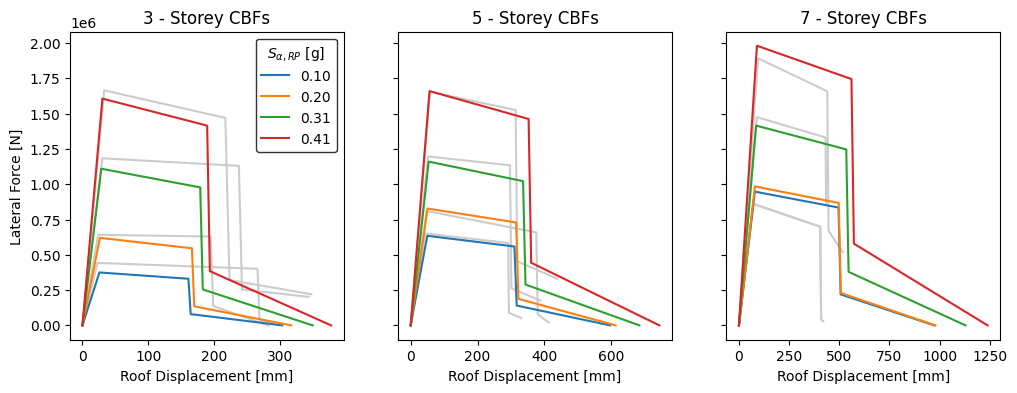

In [37]:
# Calculate the backbone curves
colours = list(TABLEAU_COLORS.values())

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, bs, ns in zip([ax1, ax2, ax3], [three_s, five_s, seven_s], [3, 5, 7]):

    for b, colour in zip(bs[:4], colours):
        # plot the po curve
        bb = bbs[b]
        h = df.loc[b, "roof_height"] / 1000         # in m; same as regression
        Vbc = df.loc[b, "Vb_coeff"]                 # unitless; same as regression
        sac = df.loc[b, "seismic_action_class"]
        Wt = df.loc[b, "Wt"]                        # in N
        appx_bb = approximate_bb(h, Vbc, sac, Wt)
        sa = bdata_df.loc[b, "S_alpha_RP"]
        ax.plot(bb[:, 0], bb[:, 1], color="0.8", zorder=5)
        ax.plot(appx_bb[:, 0], appx_bb[:, 1], color=colour, label = f"{sa:.2f}", zorder=10)
   
    ax.set_xlabel("Roof Displacement [mm]")
    ax.set_title(f"{ns} - Storey CBFs")
ax1.set_ylabel("Lateral Force [N]")
legend = ax1.legend(title=r"$S_{\alpha, RP}$ [g]")
frame = legend.get_frame()
frame.set_edgecolor("black")

Why is there such a big difference between the normalised curves?

Check to see what storey each structure is failing in...

NameError: name 'recorders_3' is not defined

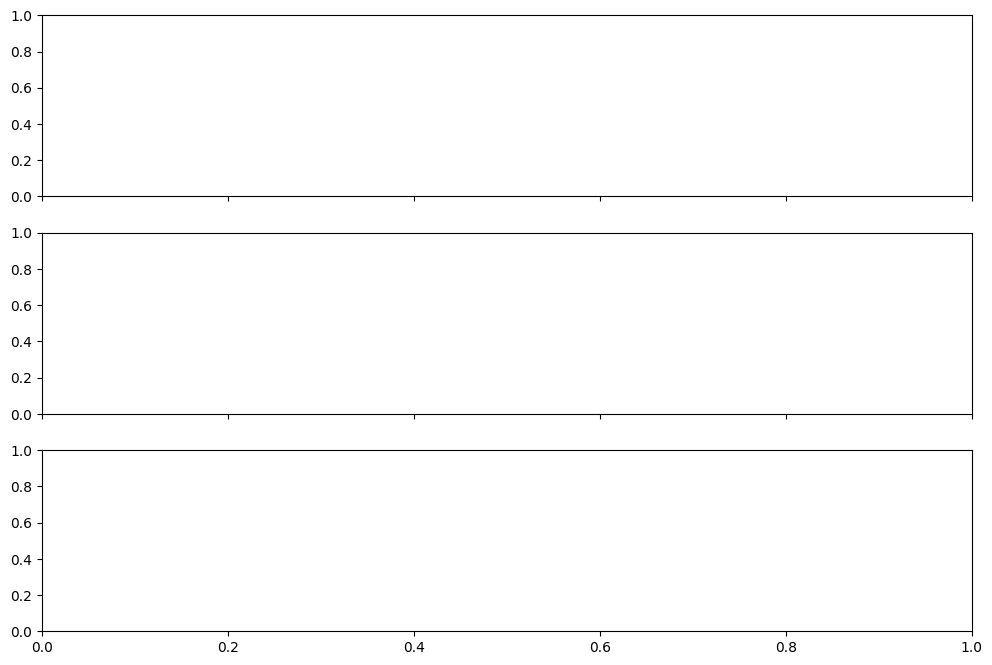

In [35]:
fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(12,8), sharex=True)

for sa, recorders in recorders_3.items():

    npoc = n_pocs3[sa]

    d1 = get_recorder(recorders, "drift", 101010200).record["res"]
    d2 = get_recorder(recorders, "drift", 101010300).record["res"]
    d3 = get_recorder(recorders, "drift", 101010400).record["res"]

    ax1.plot(npoc[:, 0], d1, label=sa)
    ax2.plot(npoc[:, 0], d2)
    ax3.plot(npoc[:, 0], d3)

ax1.set_ylabel("S1 Drift [-]")
ax2.set_ylabel("S2 Drift [-]")
ax3.set_ylabel("S3 Drift [-]")
ax1.legend()

All of them are failing in the first storey as evidenced by the very large drifts in this storey and the long flat portions of the curves in the other stories

Compare the design tension and compression utilisation ratios for each braces in the bottom storey of each structure

In [ ]:
def _get_brace_check_data(model, brace_tag):
    E_plus = model.final_checks["GQEI+"].checks[0].check_data[brace_tag].checks
    E_minus = model.final_checks["GQEI-"].checks[0].check_data[brace_tag].checks

    eta_tension = E_plus[-1].eta
    eta_buckling = E_minus[-1].eta
    slenderness = E_minus[1].check_data["slenderness"]
    N_rd = E_plus[-1].check_data["N_Rd"]
    N_ed_t = E_plus[-1].check_data["N_Ed"]
    N_brd = min(E_minus[-1].check_data["N_Rd"])
    N_ed_b = E_minus[-1].check_data["N_Ed"]
    return eta_tension, eta_buckling, slenderness, N_rd, N_ed_t, N_brd, N_ed_b

Text(0.5, 0, 'S_alpha [g]')

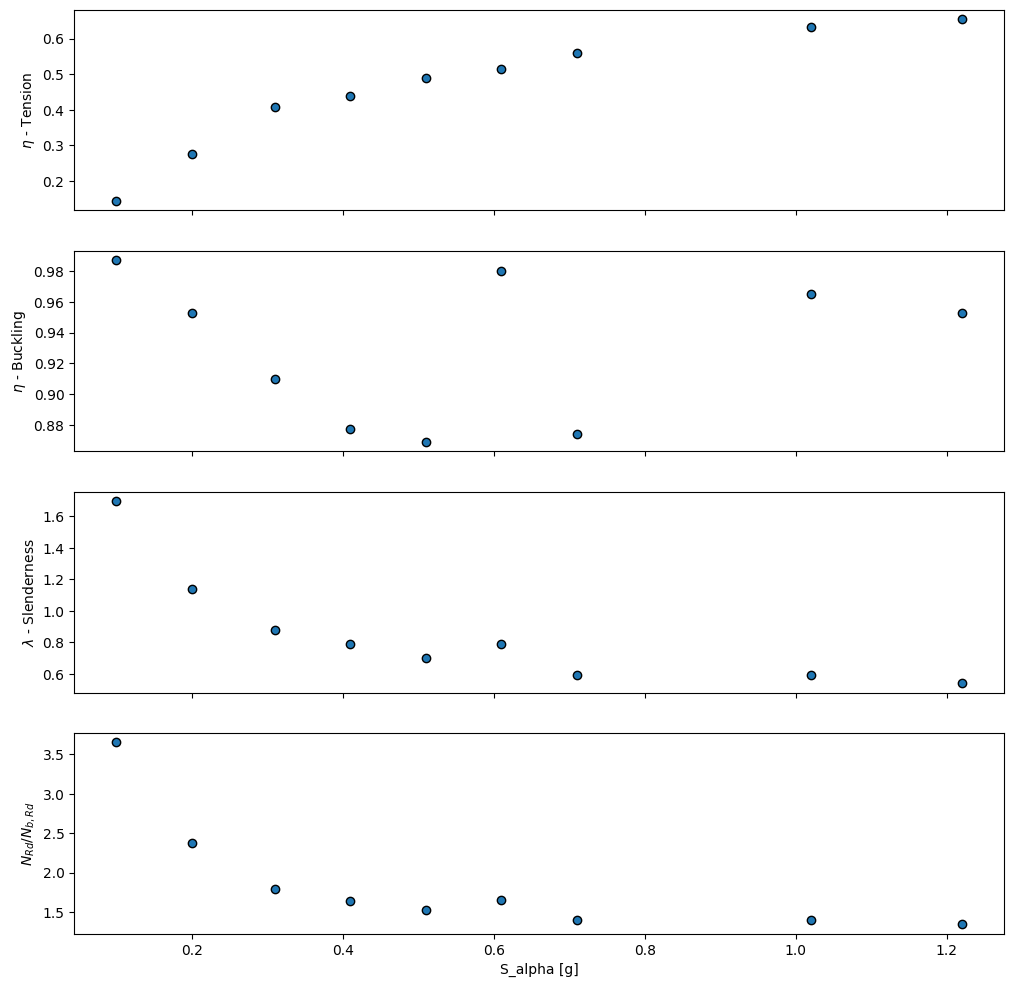

In [ ]:
# load the pickle file from the design
design_pickle_folder = cfg["models"]["casestudy_designs_ec8_gen2"]

eta_ts = []
eta_bs = []
slenderness = []
sas = []
N_rds = []
N_ed_ts = []
N_brds = []
N_ed_bs = []

for b in three_s:
    sas.append(float(b.split("_")[-1])/100)
    fp = design_pickle_folder / b/ f"{b}_out.pickle"

    with open(fp, "rb") as file:
        design = pickle.load(file)

    et, eb, sl, nrd, nedt, nbrd, nedb = _get_brace_check_data(design, 401010100)   # ground floor brace
    eta_ts.append(et)
    eta_bs.append(eb)
    slenderness.append(sl)
    N_rds.append(nrd)
    N_ed_ts.append(nedt)
    N_brds.append(nbrd)
    N_ed_bs.append(nedb)

N_rd_ratio = np.array(N_rds) / np.array(N_brds)

fig, [ax1, ax2, ax3, ax4] = plt.subplots(4, 1, figsize=(12,12), sharex=True)

ax1.plot(sas, eta_ts, ls="", marker="o", mec="k")
ax2.plot(sas, eta_bs, ls="", marker="o", mec="k")
ax3.plot(sas, slenderness, ls="", marker="o", mec="k")
ax4.plot(sas, N_rd_ratio, ls="", marker="o", mec="k")

ax1.set_ylabel(r"$\eta$ - Tension")
ax2.set_ylabel(r"$\eta$ - Buckling")
ax3.set_ylabel(r"$\lambda$ - Slenderness")
ax4.set_ylabel("$N_{Rd}$/$N_{b,Rd}$")
ax4.set_xlabel("S_alpha [g]")

I suspect the much larger normalised pushover curve for the SA_RP 0.1g and 0.2g  structures is due to the much larger ratio between the tension and buckling capacity of the braces...

In [ ]:
eta_ratio = np.array(eta_bs) / np.array(eta_ts)

In [ ]:
building_df_3s["site_category"]

0         low
1         low
2    moderate
3    moderate
4        high
5        high
6        high
7        high
8        high
Name: site_category, dtype: object